In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class Configuration:
    def __init__(self, NUM: int, rule: list, t: int = 100):
        
        self.NUM = NUM
        self.time_of_life = t
        self.rule = rule

        self.lattice = np.array([np.random.randint(0, 2, NUM) for _ in range(NUM)])
        
        self.weights = np.array([pow(2,i) for i in range(9)])

    def _get_rule_num(self) -> np.ndarray:
        weights = self.weights
        lattice = self.lattice
        n = (
            weights[0] * np.roll(lattice, (1,1), axis=(0,1)) + weights[1] * np.roll(lattice, 1, axis=0) + weights[2] * np.roll(lattice, (1,-1), axis=(0,1)) +
            weights[3] * np.roll(lattice, 1, axis=1) + weights[4] * lattice + weights[5] * np.roll(lattice, -1, axis=1) +
            weights[6] * np.roll(lattice, (-1,1), axis=(0,1)) + weights[7] * np.roll(lattice, -1, axis=0) + weights[8] * np.roll(lattice, (-1,-1), axis=(0,1))
        )
        return n

    def _update_lattice(self):
        n = self._get_rule_num()
        self.lattice = self.rule[n]

    def _fit_function(self) -> np.ndarray:
        scores = np.zeros_like(self.lattice, dtype=np.float64)
        lattice = self.lattice
    
        scores += np.where(np.roll(lattice, (1,1), axis=(0,1)) == lattice, 8, -5)
        scores += np.where(np.roll(lattice, (-1,1), axis=(0,1)) == lattice, 8, -5)
        scores += np.where(np.roll(lattice, (1,-1), axis=(0,1)) == lattice, 8, -5)
        scores += np.where(np.roll(lattice, (-1,-1), axis=(0,1)) == lattice, 8, -5)

        scores += np.where(np.roll(lattice, 1,  axis=0) != lattice, 8, -5)
        scores += np.where(np.roll(lattice, 1,  axis=1) != lattice, 8, -5)
        scores += np.where(np.roll(lattice, -1, axis=0) != lattice, 8, -5)
        scores += np.where(np.roll(lattice, -1, axis=1) != lattice, 8, -5)
        
        return scores
        
    def simulate_lifetimes(self) -> float:
        for _ in range(self.time_of_life - 11):
            self._update_lattice()
        finess = []
        for _ in range(11):
            self._update_lattice()
            finess.append(np.sum(self._fit_function()))
        return np.average(finess)
        
    def plot_fitness_function(self):
        fitness = []
        for _ in range(self.time_of_life):
            self._update_lattice()
            fitness.append(np.sum(self._fit_function()))
        plt.plot(fitness)
        
    def plot_lattice(self):
        top_score = -np.inf
        top_lattice = self.lattice.copy()
        for _ in range(self.time_of_life):
            self._update_lattice()
            score = np.sum(self._fit_function())
            if score > top_score:
                top_lattice = self.lattice.copy()
                top_score = score

        plt.imshow(top_lattice, interpolation="nearest", cmap="Greys")
        plt.axis("off")

In [18]:
class Evolution:
    def __init__(self, num_of_rules: int = 20, num_of_cells: int = 50, t: int = 100):
        self.num_of_rules = num_of_rules
        self.NUM = num_of_cells
        self.t = t
        
        self.rules = np.array([np.random.randint(0,2,512) for _ in range(self.num_of_rules)])
        self.top_rule = self.rules[0]
        self.top_score = -np.inf
        self.fitness_life = []

    def _competition(self, est_num_of_clones: int) -> np.ndarray:
        rules_score = []
        for rule in self.rules:
            conf = Configuration(NUM=self.NUM, rule=rule, t=self.t)
            rules_score.append(max(conf.simulate_lifetimes(), 0))
        total_score = np.sum(rules_score) + 1e-9
        rules_score = np.array(rules_score)
        top_score = rules_score.max()
        
        if top_score > self.top_score:
            self.top_score = top_score
            self.top_rule = self.rules[rules_score.argmax()]
        else:
            self.rules[rules_score.argmax()] = self.top_rule
        
        return np.array([round(score/total_score*est_num_of_clones) for score in rules_score])

    def _children(self, top_rules: np.ndarray, num_of_childs: int) -> np.ndarray:
    
        def mutation(rules: np.ndarray, mut_rate: float = 0.01):
            mask = np.random.random(rules.shape) < mut_rate
            rules ^= mask
            return rules
    
        num_of_rules = len(top_rules)
        children = []
        for _ in range(num_of_childs):
            p1 = top_rules[np.random.randint(num_of_rules)]
            p2 = top_rules[np.random.randint(num_of_rules)]
        
            mask = np.random.randint(0, 2, 512).astype(bool)
        
            child = np.where(mask, p1, p2)
            children.append(child)
        return mutation(np.array(children))

    def _new_generation(self, est_num_of_clones: int = 0) -> np.ndarray:
        if est_num_of_clones <= 0:
            results = self._competition(self.num_of_rules // 2)
        else:
            results = self._competition(est_num_of_clones)
        self.fitness_life.append(self.top_score)
        if np.sum(results) == 0:
            results[0] = 1 

        new_rules = np.repeat(self.rules, results, axis=0)
        return np.concatenate([new_rules, self._children(new_rules, self.num_of_rules - len(new_rules))], axis=0)
        
    def get_top_rule(self) -> np.ndarray:
        return self.top_rule
        
    def find_best(self, time_of_life: int) -> Configuration:
        for _ in range(time_of_life):
            self.rules = self._new_generation()

        rule = self.get_top_rule()
        conf = Configuration(NUM=self.NUM, rule=rule, t=self.t)
        conf.simulate_lifetimes()
        return conf
        
    def plot_fitness(self):
        plt.plot(self.fitness_life, c = 'r')
        plt.xlabel('Time')
        plt.ylabel('Score')

In [4]:
evol50 = Evolution(num_of_cells=50)
conf50 = evol50.find_best(300)

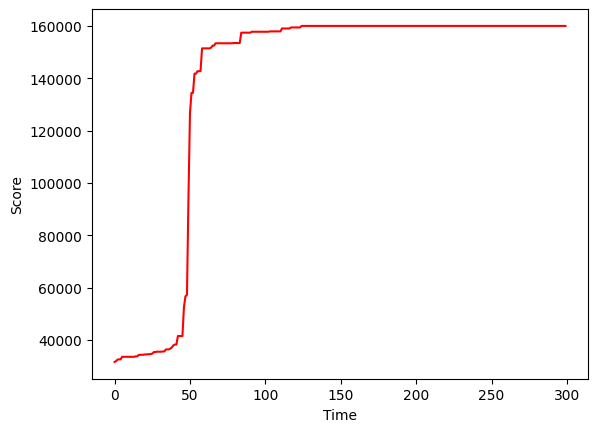

In [5]:
evol50.plot_fitness()

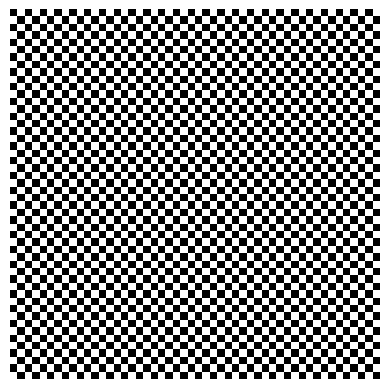

In [6]:
conf50.plot_lattice()

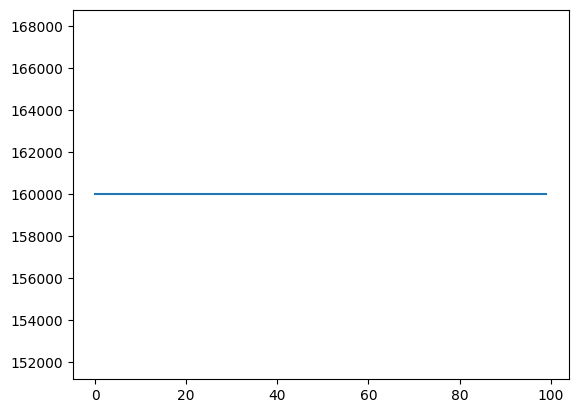

In [16]:
conf50.plot_fitness_function()

In [7]:
top_rule50 = evol50.get_top_rule()

In [12]:
evol100 = Evolution(num_of_cells=100)
conf100 = evol100.find_best(400)

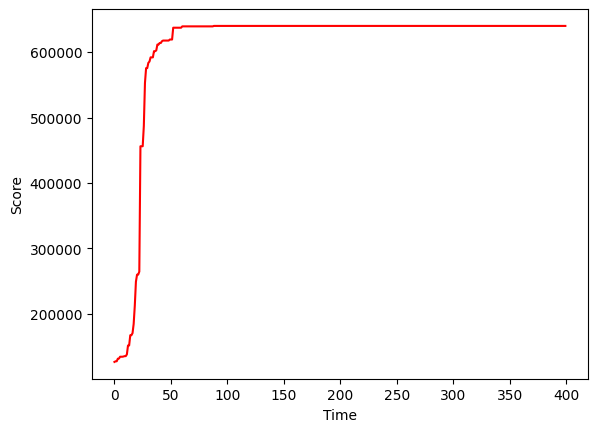

In [13]:
evol100.plot_fitness()

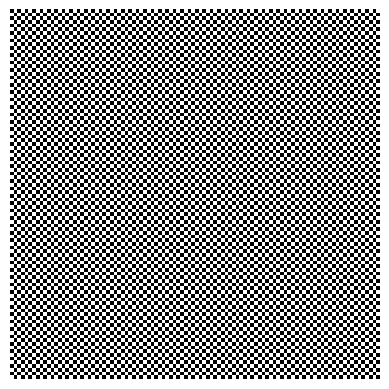

In [14]:
conf100.plot_lattice()

In [15]:
top_rule100 = evol100.get_top_rule()